In [4]:
import matplotlib.pyplot as plt
import pandas as pd

In [5]:
df_exp1 = pd.read_csv('data/resultados_exp1.csv')
t_prom_exp1 = df_exp1['tiempo_total'].mean()

df_exp2 = pd.read_csv('data/resultados_rendimiento.csv')

df_prom = df_exp2.groupby('Streams').mean().reset_index()
df_prom['var'] = df_exp2.groupby('Streams')['Tiempo_ms'].var().reset_index()['Tiempo_ms']

/tmp/ipykernel_13669/2846711206.py:2: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  t_prom_1s = float(stream1['Tiempo_ms'])


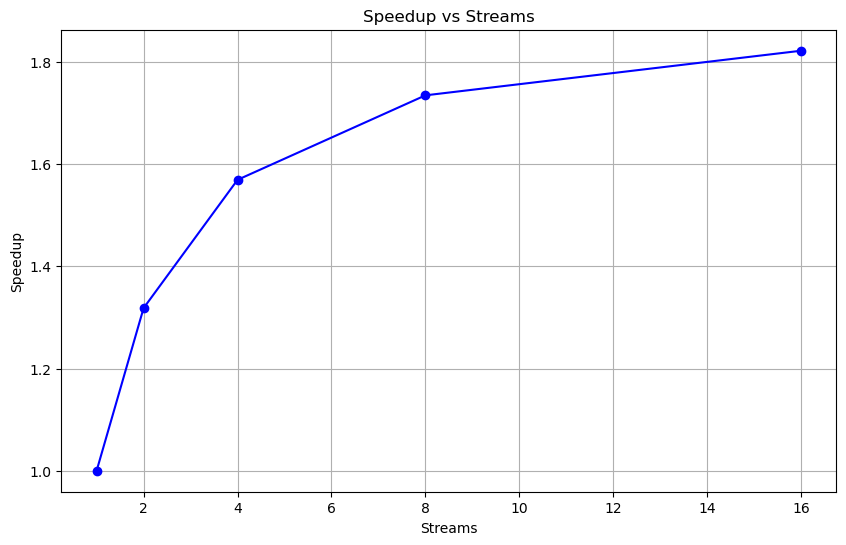

In [6]:
stream1 = df_prom[df_prom['Streams'] == 1]
t_prom_1s = float(stream1['Tiempo_ms'])

speedup = t_prom_1s /df_prom['Tiempo_ms'] 
eficiencia = speedup / df_prom["Streams"]

plt.figure(figsize=(10, 6))
plt.plot(df_prom['Streams'], speedup, marker='o', linestyle='-', color='b')
plt.title('Speedup vs Streams')
plt.xlabel('Streams')
plt.ylabel('Speedup')
plt.grid()
plt.savefig('speedup_vs_streams.png')


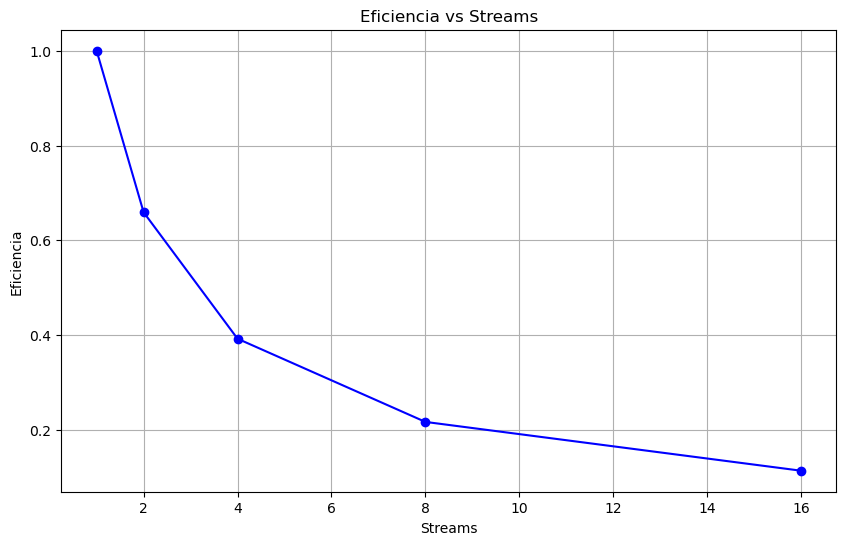

In [7]:
plt.figure(figsize=(10, 6))
plt.plot(df_prom['Streams'], eficiencia, marker='o', linestyle='-', color='b')
plt.title('Eficiencia vs Streams')
plt.xlabel('Streams')
plt.ylabel('Eficiencia')
plt.grid()
plt.savefig('eficiencia_vs_streams.png')